# XLand-MiniGrid Data Analysis


In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
from nicewebrl import data_analysis
from flax import serialization
import jax

In [75]:
from nicewebrl.utils import read_all_records

file_path = "/Users/vikramgoddla/nicewebrl_LLM_EnvStage/nicewebrl/examples/xland-LLM-assistant/data/user_data_419883358.msgpack"
data_dicts = await read_all_records(file_path)

In [77]:
len(data_dicts)

154

In [78]:
from collections import Counter

# Count field frequencies inside "data"
field_counts = Counter(k for d in data_dicts for k in d.get('data', {}).keys())
print(field_counts.most_common(20))

# Peek at the last few records to see why [-1] didn't have action_taken_time
for d in data_dicts[-5:]:
    print(d.get('type'), list(d.get('data', {}).keys()))

[('image_seen_time', 153), ('action_taken_time', 153), ('computer_interaction', 153), ('action_name', 153), ('action_idx', 153), ('timelimit', 153), ('timestep', 153), ('llm_chat_history', 64), ('How helpful was the AI?', 1), ('How human-like was the AI?', 1)]
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep', 'llm_chat_history']
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep', 'llm_chat_history']
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep', 'llm_chat_history']
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep']
None ['How helpful was the AI?', 'How human-like was the AI?']


In [79]:
def has_keys(d, *ks):
    return all(k in d.get('data', {}) for k in ks)

action_recs = [d for d in data_dicts
               if has_keys(d, 'image_seen_time', 'action_taken_time')]
print(len(action_recs), "action timesteps")

153 action timesteps


In [80]:
from nicewebrl import time_diff

def has_str(d, key):
    v = d.get('data', {}).get(key)
    return isinstance(v, str) and len(v) > 0

# keep only *valid* action records with both times present as strings
action_recs = [
    d for d in data_dicts
    if has_str(d, 'image_seen_time') and has_str(d, 'action_taken_time')
]

# FIRST valid image_seen_time anywhere in the stream
first_image_ts = next(
    d['data']['image_seen_time'] for d in data_dicts if has_str(d, 'image_seen_time')
)

# LAST valid action_taken_time among action records
last_action_ts = next(
    d['data']['action_taken_time'] for d in reversed(action_recs)
)

start_end_sec = time_diff(first_image_ts, last_action_ts) / 1000
print(f"Total seconds from first timestep to last action: {start_end_sec:.2f}")

pair_ms = [
    time_diff(d['data']['image_seen_time'], d['data']['action_taken_time'])
    for d in action_recs
]
total_timestep_sec = sum(pair_ms) / 1000
print(f"Total seconds across image–action pairs: {total_timestep_sec:.2f}")

Total seconds from first timestep to last action: 61.70
Total seconds across image–action pairs: 83.37


In [81]:
from pprint import pprint

datum = data_dicts[0]
print("-----")
pprint(list(datum.keys()))
print("--- data ---")
pprint(list(datum["data"].keys()))

-----
['stage_idx', 'session_id', 'data', 'user_data', 'metadata', 'name', 'body']
--- data ---
['image_seen_time',
 'action_taken_time',
 'computer_interaction',
 'action_name',
 'action_idx',
 'timelimit',
 'timestep']


In [82]:
print("------")

for key in [
  # "id",  # time-step idx. global
  "session_id",  # browser session id
  "stage_idx",
]:
  print(key, ":", datum[key])

print("--- data ---")
for key in [
  "image_seen_time",
  "action_taken_time",
  "computer_interaction",
  "action_name",
  "action_idx",
]:
  print(key, ":", datum["data"][key])

------
session_id : 630f37f7-578b-4561-a2a7-9f95c3223383
stage_idx : 1
--- data ---
image_seen_time : 2025-08-24T01:30:31.067Z
action_taken_time : 2025-08-24T01:30:32.197Z
computer_interaction : ArrowUp
action_name : Forward
action_idx : 0


In [84]:
datum["metadata"]  # remember, this is for the VERY FIRST timestep of this episode

{'stage_number': 1,
 'type': 'EnvStage',
 'unique_id': 'stage_8563fd0dd216483fa69c0bae48198dda',
 'nsteps': 2,
 'nepisodes': 1,
 'nsuccesses': 0}

In [85]:
datum["user_data"]

{'user_id': 419883358, 'age': 19, 'sex': 'Male'}

In [86]:
def is_str(v): return isinstance(v, str) and len(v) > 0

img_idxs, img_ts = [], []
act_idxs, act_ts = [], []
for i, d in enumerate(data_dicts):
    dd = d.get('data', {})
    if is_str(dd.get('image_seen_time')):
        img_idxs.append(i); img_ts.append(dd['image_seen_time'])
    if is_str(dd.get('action_taken_time')):
        act_idxs.append(i); act_ts.append(dd['action_taken_time'])

print(f"records={len(data_dicts)}  images={len(img_idxs)}  actions={len(act_idxs)}")
print("first image idx:", img_idxs[0] if img_idxs else None, "| ts:", img_ts[0] if img_ts else None)
print("first action idx:", act_idxs[0] if act_idxs else None, "| ts:", act_ts[0] if act_ts else None)
print("image idxs (first 10):", img_idxs[:10])
print("action idxs (first 10):", act_idxs[:10])


records=154  images=153  actions=153
first image idx: 0 | ts: 2025-08-24T01:30:31.067Z
first action idx: 0 | ts: 2025-08-24T01:30:32.197Z
image idxs (first 10): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
action idxs (first 10): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [87]:
datum = data_dicts[0]["data"]
action_taken: int = datum["action_idx"]
image_seen_time: str = datum["image_seen_time"]
action_taken_time: str = datum["action_taken_time"]
reaction_time: float = data_analysis.compute_reaction_time(datum)

print(f"Reaction time: {reaction_time:.2f} milliseconds")

Reaction time: 1130.00 milliseconds


In [88]:
import jax
from experiment_structure import jax_env, env_params, render_fn

example_timestep = jax_env.reset(key=jax.random.PRNGKey(0), params=env_params)

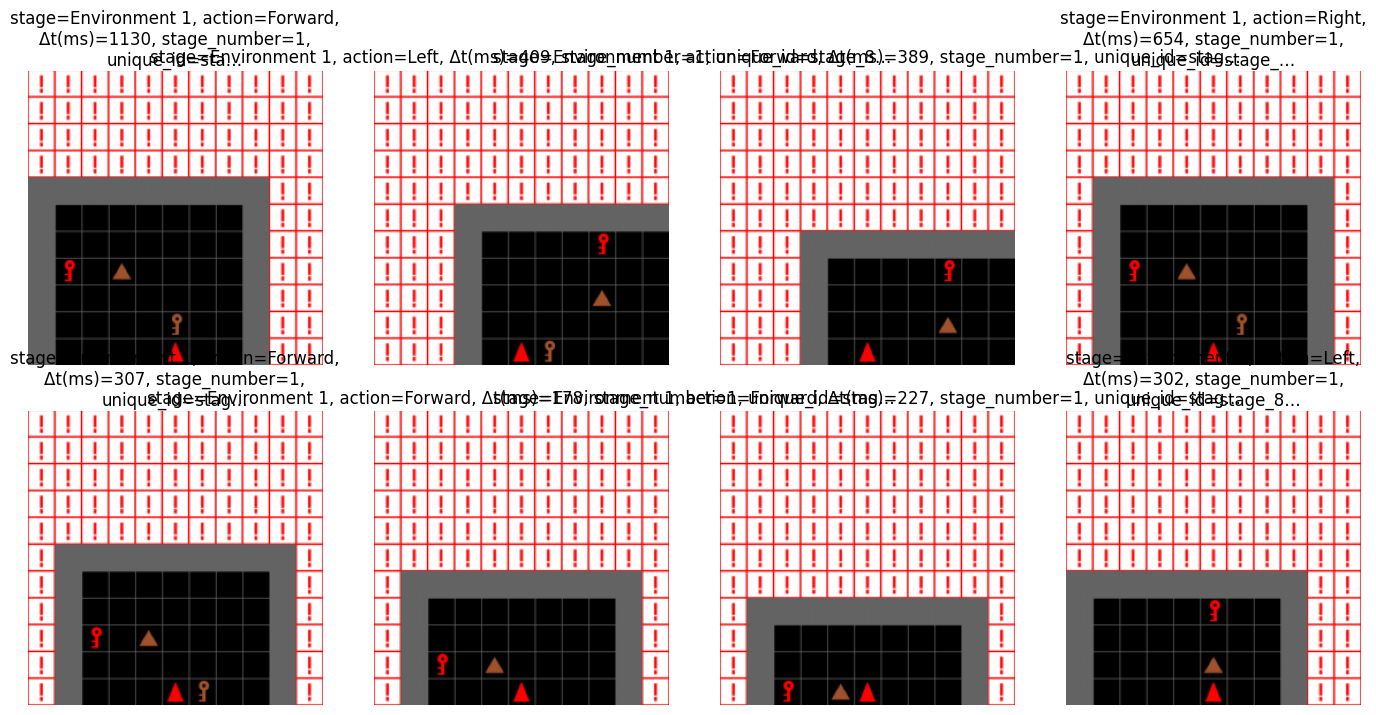

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from flax import serialization

# --- pick a renderer from your codebase ---
try:
    # your project: experiment_structure.py exports render_fn
    from experiment_structure import render_fn as RENDER
except Exception:
    RENDER = None

def dict_to_string(data: dict) -> str:
    return ", ".join(f"{k}={v}" for k, v in data.items())

def shorten(s: str, width: int = 70, placeholder: str = "…") -> str:
    return s if len(s) <= width else s[: max(0, width - len(placeholder))] + placeholder

# Show the first N timesteps as a grid.
# Requires `example_timestep` (a template) and `data_dicts` already loaded.
def show_timesteps(data_dicts, example_timestep, n=6):
    assert RENDER is not None, (
        "Couldn't import a renderer. Make sure experiment_structure.py is on the PYTHONPATH "
        "and exports `render_fn`, or set RENDER to your renderer function."
    )

    # layout
    n = min(n, len(data_dicts))
    cols = min(4, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = np.atleast_1d(axes).ravel()

    # optional time delta helper
    try:
        from nicewebrl import time_diff  # returns milliseconds
    except Exception:
        time_diff = None

    for i in range(n):
        datum = data_dicts[i]
        meta = datum.get("metadata", {})
        dd   = datum.get("data", {})

        # reconstruct timestep
        ts_bytes = dd["timestep"]
        timestep = serialization.from_bytes(example_timestep, ts_bytes)

        # render
        img = RENDER(timestep).astype(np.uint8)

        # build a compact title
        act_name = dd.get("action_name")
        key      = dd.get("computer_interaction")
        img_t    = dd.get("image_seen_time")
        act_t    = dd.get("action_taken_time")

        dt_ms = None
        if time_diff and isinstance(img_t, str) and isinstance(act_t, str):
            try:
                dt_ms = round(time_diff(img_t, act_t))
            except Exception:
                dt_ms = None

        title_bits = {
            "stage": datum.get("name"),
            "action": act_name or key,
            "Δt(ms)": dt_ms,
        }
        # include a couple of metadata keys if present
        for k in ("stage_number", "unique_id"):
            if k in meta:
                title_bits[k] = meta[k]

        title = dict_to_string({k: v for k, v in title_bits.items() if v not in (None, "", [])})
        title = shorten(title, 80)

        ax = axes[i]
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(title, wrap=True)

    # hide unused axes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# --- example usage ---
# show the first 8 timesteps
show_timesteps(data_dicts, example_timestep, n=8)

In [90]:
import pandas as pd

def extract_latest_llm_turns(data_dicts):
    rows = []
    for rec in data_dicts:
        data = rec.get("data", {}) or {}
        hist = data.get("llm_chat_history")
        if not hist:
            continue
        if isinstance(hist, dict):
            hist = [hist]
        if not isinstance(hist, list):
            continue

        # only grab the latest turn in this record
        last = hist[-1]
        rows.append({
            "timestamp": last.get("timestamp"),
            "stage": rec.get("name"),
            "turn": len(hist),
            "prompt": last.get("prompt") or "",
            "response": last.get("response") or "",
        })

    df = pd.DataFrame(rows)
    if not df.empty:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        # group by stage, keep only the first (latest turn seen per stage)
        df = df.groupby("stage", as_index=False).last()
        df = df.sort_values("timestamp").reset_index(drop=True)
    return df

df_llm = extract_latest_llm_turns(data_dicts)

if df_llm.empty:
    print("No LLM prompt history found.")
else:
    print(f"Unique prompt submissions found: {len(df_llm)}")
    display(df_llm[["timestamp","stage","turn","prompt","response"]])

Unique prompt submissions found: 2


,timestamp,stage,turn,prompt,response
0,2025-08-24 01:30:46.982411+00:00,Environment 1,1,i'm confused what to do,"Here's a concise, step-by-step guide to progre..."
1,2025-08-24 01:31:23.725410+00:00,Environment 3,1,"hmm, what now? Do i need to collect a key?","Yes, you need to collect the red key located a..."
